<a href="https://colab.research.google.com/github/thahsinj06/Fly-rank-ml-internship-work/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thahsinj06/Fly-rank-ml-internship-work/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can a simple machine-learning model identify content that shows a higher measured likelihood of decline, and can that signal improve how a content team prioritizes pages for human review?

### Decision supported

The output supports one practical decision:

**Which content should a team review first?**

The unit of analysis is an individual content item. The model produces a decline probability for each item, which is then converted into a priority rank and an action category:

* **REFRESH** — highest-priority items for human review
* **REVIEW** — moderate-priority items
* **MONITOR** — lower-priority items

The model is not intended to automatically decide what happens to a page. A reviewer should consider the page's current intent, quality, business importance, recent performance, and update history before taking action.

### Why use ML?

A simple rule can already identify content using signals such as impressions and staleness. ML is useful here because several signals can be considered together and converted into a consistent ranking across many content items.

The goal is therefore not to build the most complex model possible. The goal is to test whether a simple, reproducible ML model provides useful decision-support beyond a transparent rule-based baseline.


In [1]:
import pandas as pd
import numpy as np

# Load the anonymized FlyRank internship dataset
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "thahsinj06/Fly-rank-ml-internship-work/"
    "main/data/raw/content_refresh_anonymized.csv"
)
df = pd.read_csv(DATA_URL)

# Define the binary decline label
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Dataset shape:", df.shape)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget percentage:")
print(
    df["is_declining_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset shape: (30000, 45)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target percentage:
is_declining_label
1    54.21
0    45.79
Name: proportion, dtype: float64


## 2. Data

The analysis uses the anonymized FlyRank ML Internship dataset provided for the content-refresh task. The working release contains **30,000 content records** and combines search-performance, content, freshness, and engagement signals at the content-item level.

The main analysis uses fields such as search volume, 90-day impressions, content age/freshness, average search position, and CTR. The target is derived from the supplied trend direction field:

`is_declining_label = 1` when `trend_direction = "down"`, otherwise `0`.

### Fields deliberately excluded

Several fields were not used as model features:

* **`trend_direction`** — excluded because it directly defines the target and would cause target leakage.
* **`trend_pct`** — excluded because it is directly related to the supplied trend outcome.
* **`content_id`** — retained only as an identifier for the ranked output, never used as a predictive feature.
* **`client_id`** — not used as a predictive feature. It is used only for grouped validation to test whether performance changes when content from the same client is kept together.
* Other descriptive or categorical fields were not included in the final Week-5 model because the capstone focuses on testing a small, interpretable feature set rather than maximizing model complexity.

### Time and leakage considerations

The available dataset does not provide enough information to reconstruct an exact future-only prediction window. Therefore, the analysis does not claim to be a fully time-sealed forecasting experiment.

The final model excludes the supplied target-derived trend fields. However, some performance variables may overlap with the period used to construct the supplied label. This is treated as a remaining temporal-overlap risk and limits how strongly the results can be interpreted.

### Public safety

The analysis uses the anonymized dataset supplied for the internship. Client-identifying information, private queries, credentials, domains, and other identifying details are not included in the analysis or intended for the public-facing paper.


## 3. Methodology

The goal was to compare a simple rule-based approach with a machine-learning model.

### Target

The target is `is_declining_label`.

* `1` = the content is marked as declining
* `0` = the content is not marked as declining

The label comes from the dataset's `trend_direction` field.

### Baseline

The first approach was a simple scoring rule. It uses two signals:

* 90-day impressions
* Days since the content was last updated

Higher impressions and older content increase the priority score. The rule then places content into **REFRESH**, **REVIEW**, or **MONITOR**.

This is a useful baseline because it is simple, easy to understand, and does not use the machine-learning target.

### ML model

The machine-learning model is **Logistic Regression**.

It was chosen because it is simple, fast, and easy to interpret. The aim was to see whether combining several useful signals could improve the prioritization task without using a complex model.

The five features used were:

1. `search_volume`
2. `impressions_90d`
3. `days_since_last_update`
4. `avg_position`
5. `ctr`

The model does **not** use `trend_direction` or `trend_pct` because they are directly related to the target.

### Validation

The main evaluation uses an **80/20 stratified random split** with `random_state = 42`.

The model was also tested using a **client-grouped split**. In this test, content from the same client is kept together instead of being randomly mixed between training and testing.

This second test is stricter because it checks whether the model still works when it sees clients that were not present in training.

### Leakage check

The target-related fields were removed from the model features. `client_id` was also kept out of the model because it is an identifier, not a meaningful prediction signal.

However, the exact time period used to create the supplied trend label is not available. Some performance features may therefore overlap with the period used to create the label. The results should be treated as directional rather than as proof of future forecasting performance.


## 4. Results (vs baseline)

The machine-learning model was compared with the rule-based baseline using the same prediction task.

The majority class makes up **54.21%** of the dataset, so accuracy should be viewed together with the other metrics.

| Metric    | Rule-based baseline | Logistic Regression |
| --------- | ------------------: | ------------------: |
| Accuracy  |               0.541 |               0.557 |
| Precision |               0.596 |               0.558 |
| Recall    |               0.475 |               0.873 |
| F1 score  |               0.529 |           **0.681** |

The Logistic Regression model had a higher F1 score than the baseline (**0.681 vs 0.529**). Its recall was also much higher (**0.873 vs 0.475**), meaning it found a much larger share of the content labelled as declining.

The trade-off was lower precision (**0.558 vs 0.596**). In simple terms, the model catches more potentially declining content, but it also flags more content that may not actually be declining.

For this use case, the higher recall is useful because the model is being used as a **screening and prioritization tool**, rather than making an automatic final decision.

The stricter client-grouped validation gave an F1 score of **0.648**, compared with **0.681** on the random split. This drop suggests that the random split gives somewhat more favorable results, but performance did not collapse when content was grouped by client.


## 5. Limitations

This analysis has several limitations.

* The dataset does not provide enough information to create a fully time-separated future prediction test. Some features may overlap with the period used to create the supplied trend label.
* The target is based on the dataset's existing `trend_direction` field. It is a proxy for decline, not a direct measure of future business performance.
* The model was tested on one main random split and one client-grouped split. More time-based and client-held-out testing would give stronger evidence of real-world performance.
* The model does not prove that content age, impressions, position, or any other feature **causes** content to decline.
* A high decline probability does not mean that refreshing the content will improve its performance.
* The model is designed for prioritization, not automatic publishing, deletion, redirection, or other content changes.
* The dataset is anonymized and may not represent every type of website, industry, or search environment.

Therefore, the results should be treated as **measured and directional evidence for decision-support**, rather than guaranteed predictions of future performance.


## 6. Ranked recommendations

The model produces a decline probability for each content item. The items are then ranked from highest to lowest risk so that a content team can start with the pages that need the most attention.

The recommended actions are:

1. **REFRESH** — Review the highest-risk content first. Check whether the content is outdated, no longer matches the search intent, or has lost useful information.
2. **REVIEW** — Check medium-risk content after the highest-priority items. A refresh may be useful, but the model score alone is not enough to make that decision.
3. **MONITOR** — Keep lower-risk content under normal observation rather than spending immediate editing effort on it.

The ranking can help a content team decide **where to spend review time first** instead of checking every page equally.

### How to use the output

A reviewer can start at the top of the ranked queue and inspect each page using the model score together with other available evidence. The reviewer should then decide whether to refresh, leave unchanged, or investigate the page further.

The confidence in these recommendations is **moderate**. The model showed useful screening performance, especially its high recall, but the client-grouped validation score was lower than the random-split result.

The output should therefore be treated as **decision-support, not an automatic decision system**. The model identifies content worth looking at first; a human decides what should actually happen.


## 7. Artifacts the paper embeds

The deployed paper will use a small set of charts and tables to make the results easy to understand.

The main artifacts are:

1. **Target distribution** — shows the percentage of content labelled as declining and not declining.
2. **Model vs baseline table** — compares Accuracy, Precision, Recall, and F1 score.
3. **Validation comparison** — shows how the F1 score changes between the random split and client-grouped split.
4. **Ranked action summary** — shows how many content items fall into REFRESH, REVIEW, and MONITOR.
5. **Feature interpretation** — shows the direction and relative strength of the Logistic Regression features.

These artifacts are meant to support the written findings. They are not intended to prove causation or predict future search performance with certainty.


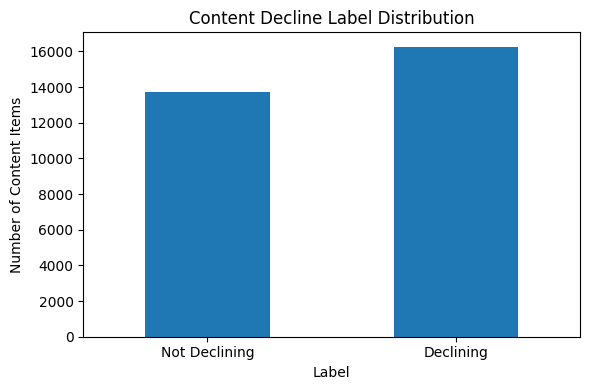

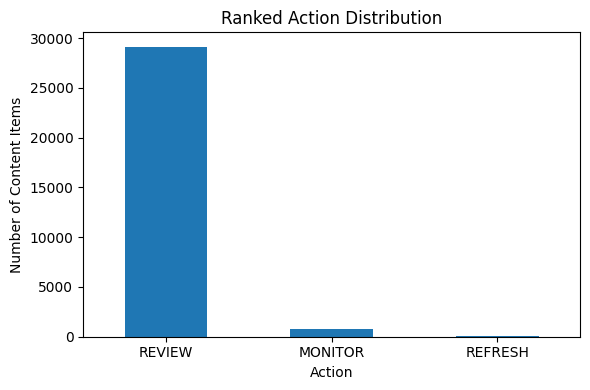

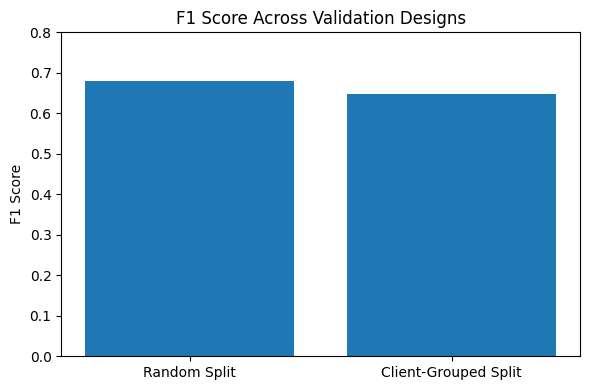

Capstone artifacts created successfully.
Rows in action queue: 30000

Action counts:
action
REVIEW     29120
MONITOR      795
REFRESH       85
Name: count, dtype: int64

Figures saved:
1. target_distribution.png
2. action_distribution.png
3. validation_f1.png


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# Setup
# --------------------------------------------------

os.makedirs("../../work/figures", exist_ok=True)

# Load data
capstone_df = pd.read_csv(
    DATA_URL
)

# Create target
capstone_df["is_declining_label"] = (
    capstone_df["trend_direction"] == "down"
).astype(int)

# --------------------------------------------------
# Build the ranked action queue
# --------------------------------------------------

features = [
    "search_volume",
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "ctr"
]

X = capstone_df[features]
y = capstone_df["is_declining_label"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Fit on all available records for the final prioritization queue
model.fit(X, y)

capstone_df["decline_probability"] = model.predict_proba(X)[:, 1]

capstone_df["action"] = np.select(
    [
        capstone_df["decline_probability"] >= 0.70,
        capstone_df["decline_probability"] >= 0.45
    ],
    [
        "REFRESH",
        "REVIEW"
    ],
    default="MONITOR"
)

# Reason codes
capstone_df["reason_code"] = np.select(
    [
        (capstone_df["days_since_last_update"] > 90) &
        (capstone_df["impressions_90d"] >= capstone_df["impressions_90d"].median()),

        capstone_df["days_since_last_update"] > 90,

        capstone_df["impressions_90d"] >= capstone_df["impressions_90d"].median(),

        capstone_df["days_since_last_update"] <= 30
    ],
    [
        "STALE_HIGH_VISIBILITY",
        "STALE_CONTENT",
        "HIGH_VISIBILITY",
        "RECENTLY_UPDATED"
    ],
    default="GENERAL_RISK"
)

queue = capstone_df.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = np.arange(1, len(queue) + 1)

# --------------------------------------------------
# 1. Target distribution
# --------------------------------------------------

target_counts = capstone_df["is_declining_label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Content Decline Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Content Items")
plt.xticks([0, 1], ["Not Declining", "Declining"], rotation=0)
plt.tight_layout()
plt.savefig("../../work/figures/target_distribution.png", dpi=200)
plt.show()


# --------------------------------------------------
# 2. Ranked action distribution
# --------------------------------------------------

action_counts = queue["action"].value_counts()

plt.figure(figsize=(6, 4))
action_counts.plot(kind="bar")
plt.title("Ranked Action Distribution")
plt.xlabel("Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../../work/figures/action_distribution.png", dpi=200)
plt.show()


# --------------------------------------------------
# 3. Validation comparison
# --------------------------------------------------

validation_f1 = pd.DataFrame({
    "Evaluation": [
        "Random Split",
        "Client-Grouped Split"
    ],
    "F1": [
        0.681,
        0.648
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(validation_f1["Evaluation"], validation_f1["F1"])
plt.ylim(0, 0.8)
plt.title("F1 Score Across Validation Designs")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.savefig("../../work/figures/validation_f1.png", dpi=200)
plt.show()


# --------------------------------------------------
# Final check
# --------------------------------------------------

print("Capstone artifacts created successfully.")
print("Rows in action queue:", len(queue))
print("\nAction counts:")
print(queue["action"].value_counts())

print("\nFigures saved:")
print("1. target_distribution.png")
print("2. action_distribution.png")
print("3. validation_f1.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12: 5-Minute Demo Outline

### 1. Problem — 45 seconds

Explain that a content team may have many pages to review, so the goal is to identify which pages should be checked first.

### 2. Data — 45 seconds

Briefly introduce the anonymized content dataset and the main signals used: search volume, impressions, freshness, average position, and CTR.

### 3. Method — 1 minute

Explain the simple rule-based baseline and the Logistic Regression model. Mention that target-derived fields were excluded to reduce leakage.

### 4. Results — 1 minute

Show the model-versus-baseline results. The Logistic Regression model achieved an F1 score of **0.681** on the random split and **0.648** on the client-grouped split.

### 5. Action output — 45 seconds

Show the ranked queue with **REFRESH, REVIEW, and MONITOR** actions. Explain that the queue helps a human decide where to look first.

### 6. Limitations — 45 seconds

Explain that the results are directional, the data has temporal-overlap limitations, and the model does not prove that refreshing content will improve performance.


I built an ML-based content prioritization system using an anonymized SEO dataset.

The project compares a simple rule-based baseline with Logistic Regression to identify content showing signs of decline. The model achieved an F1 score of 0.681 on the main test split and 0.648 on client-grouped validation.

The final output ranks content into REFRESH, REVIEW, and MONITOR categories so a human reviewer can focus on the highest-priority pages first.

The main lesson: a useful ML system does not always need to be complex — it needs to answer a clear decision question and be honest about its limits.


I built a machine-learning content prioritization system that combines search-performance and content-freshness signals to identify content that may need review.

I compared a transparent rule-based baseline with Logistic Regression and tested the model using both random and client-grouped validation.

The final system converts the model output into a ranked decision-support queue, showing how I can turn raw data and ML results into a practical business workflow.

